# Single-image inference

Classify one radio-galaxy cutout with a finetuned RGC model (BYOL-pretrained
`DSteerableLeNet` encoder + classification head).

**Classes** (in output order): `nat`, `sfri`, `sfrii`, `wat`.

**Prerequisites**
- Training dependencies installed: `pip install -r requirements.txt`.
- A finetuned checkpoint — default `checkpoints/epoch=499-step=103000.ckpt`.
- An image to classify — set `IMAGE_PATH` in the config cell, or drop cutouts under
  `checkpoints/mian_dataset/no_spurious_masked_png/<class>/` and let the notebook pick one.

Run the cells top to bottom.


In [1]:
import sys
from pathlib import Path

# Resolve the repo root so this works whether Jupyter is launched from the repo
# root or from notebooks/, then put src/ on the path for `models` / `utils`.
_cwd = Path.cwd()
REPO_ROOT = next(
    (p for p in (_cwd, *_cwd.parents) if (p / "src").is_dir() and (p / "notebooks").is_dir()),
    _cwd,
)
SRC = REPO_ROOT / "src"
if str(SRC) not in sys.path:
    sys.path.insert(0, str(SRC))

import torch
from PIL import Image
from torchvision import transforms as T

from models.downstream_trainer import BYOLDownstreamClassifier

device = "cuda" if torch.cuda.is_available() else "cpu"
print(f"repo root: {REPO_ROOT}")
print(f"device:    {device}")

repo root: /home/gate/rgc
device:    cpu


/home/gate/rgc/.rgc/lib/python3.13/site-packages/torch/cuda/__init__.py:1112: UserWarning: Can't initialize NVML
  raw_cnt = _raw_device_count_nvml()


In [2]:
# --- what to classify --------------------------------------------------------
# Class order MUST match training: torchvision.ImageFolder sorts class folders
# alphabetically, so the four output logits map to these names in this order.
CLASS_NAMES = ["nat", "sfri", "sfrii", "wat"]

# Finetuned Lightning checkpoint (the downstream classifier).
CHECKPOINT = REPO_ROOT / "checkpoints" / "epoch=499-step=103000.ckpt"

# Image to classify. Set IMAGE_PATH to a specific file, or leave it None to
# auto-pick the first sample under DATA_DIR (the masked-PNG variant used in training).
DATA_DIR = REPO_ROOT / "checkpoints" / "mian_dataset" / "no_spurious_masked_png"
IMAGE_PATH = None

if IMAGE_PATH is None:
    pngs = sorted(DATA_DIR.rglob("*.png"))
    IMAGE_PATH = pngs[0] if pngs else None
IMAGE_PATH = Path(IMAGE_PATH) if IMAGE_PATH else None

assert CHECKPOINT.is_file(), f"checkpoint not found: {CHECKPOINT}"
assert IMAGE_PATH and IMAGE_PATH.is_file(), f"no image found (set IMAGE_PATH): {IMAGE_PATH}"
print(f"checkpoint: {CHECKPOINT}")
print(f"image:      {IMAGE_PATH}")

checkpoint: /home/gate/rgc/checkpoints/epoch=499-step=103000.ckpt
image:      /home/gate/rgc/checkpoints/mian_dataset/no_spurious_masked_png/nat/nat_L0001_000115.37-082639.6_masked.png


In [3]:
# load_from_checkpoint restores the saved hyper-parameters *and* the finetuned
# weights from the checkpoint's state_dict.
#   - pretrained_path=None skips re-loading the BYOL encoder from its original
#     (now-absent) path; the finetuned weights already come from this checkpoint.
#   - experiment_root / class_names_report are not stored in the checkpoint, so
#     we pass them explicitly.
model = BYOLDownstreamClassifier.load_from_checkpoint(
    str(CHECKPOINT),
    map_location=device,
    pretrained_path=None,
    experiment_root=".",
    class_names_report=CLASS_NAMES,
)
model.eval().to(device)
print(f"loaded finetuned classifier — {model.hparams.num_classes} classes")

/home/gate/rgc/.rgc/lib/python3.13/site-packages/e2cnn/nn/modules/r2_conv/basisexpansion_singleblock.py:80: UserWarning: indexing with dtype torch.uint8 is now deprecated, please use a dtype torch.bool instead. (Triggered internally at /__w/pytorch/pytorch/aten/src/ATen/native/IndexingUtils.h:37.)
  full_mask[mask] = norms.to(torch.uint8)


loaded finetuned classifier — 4 classes


In [4]:
# Test-time preprocessing, identical to training
# (src/scripts/downstream_trainer.py -> test_transform). Images are loaded as
# single-channel grayscale, matching utils.dataloader._grayscale_loader.
preprocess = T.Compose([
    T.Resize((150, 150)),
    T.ToTensor(),
    T.Pad(padding=1, fill=0, padding_mode="constant"),
    T.Normalize(mean=[0.0032], std=[0.0376]),
])


@torch.no_grad()
def classify(image_path):
    img = Image.open(image_path).convert("L")        # grayscale, as in training
    x = preprocess(img).unsqueeze(0).to(device)      # [1, 1, 152, 152]
    logits = model(x)
    probs = torch.softmax(logits, dim=1).squeeze(0).cpu()
    pred = int(probs.argmax())
    return CLASS_NAMES[pred], probs, img

In [5]:
pred_class, probs, img = classify(IMAGE_PATH)

print(f"file:      {IMAGE_PATH.name}")
print(f"predicted: {pred_class}  ({probs.max():.1%})\n")
print("class probabilities")
for name, p in sorted(zip(CLASS_NAMES, probs.tolist()), key=lambda kv: -kv[1]):
    print(f"  {name:6s} {p:6.1%}  {'#' * int(round(p * 30))}")

file:      nat_L0001_000115.37-082639.6_masked.png
predicted: nat  (73.0%)

class probabilities
  nat     73.0%  ######################
  wat     27.0%  ########
  sfrii    0.0%  
  sfri     0.0%  


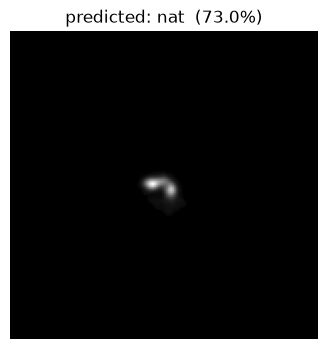

In [6]:
import matplotlib.pyplot as plt

plt.figure(figsize=(4, 4))
plt.imshow(img, cmap="gray")
plt.title(f"predicted: {pred_class}  ({probs.max():.1%})")
plt.axis("off")
plt.show()